In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
print("Libraries loaded!")

Libraries loaded!


In [4]:
df = pd.read_csv('/kaggle/input/datasets/irenejijo/best-sellers-with-categories/bestsellers with categories.csv')
print("Shape:", df.shape)
df.head()

Shape: (550, 7)


,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         550 non-null    object 
 1   Author       550 non-null    object 
 2   User Rating  550 non-null    float64
 3   Reviews      550 non-null    int64  
 4   Price        550 non-null    int64  
 5   Year         550 non-null    int64  
 6   Genre        550 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 30.2+ KB


In [6]:
df.describe()

,User Rating,Reviews,Price,Year
count,550.000000,550.000000,550.000000,550.000000
mean,4.618364,11953.281818,13.100000,2014.000000
std,0.226980,11731.132017,10.842262,3.165156
min,3.300000,37.000000,0.000000,2009.000000
25%,4.500000,4058.000000,7.000000,2011.000000
50%,4.700000,8580.000000,11.000000,2014.000000
75%,4.800000,17253.250000,16.000000,2017.000000
max,4.900000,87841.000000,105.000000,2019.000000


In [7]:
df.isnull().sum()

Name           0
Author         0
User Rating    0
Reviews        0
Price          0
Year           0
Genre          0
dtype: int64

In [27]:
# Check for duplicates
print("Duplicates:", df.duplicated().sum())
# Check column names
print(df.columns.tolist())


Duplicates: 0
['Name', 'Author', 'User Rating', 'Reviews', 'Price', 'Year', 'Genre']


In [28]:
# Rename columns to remove spaces
df.columns = ['Name', 'Author', 'User_Rating', 'Reviews', 'Price', 'Year', 'Genre']

In [16]:
# Check unique genres
print(df['Genre'].unique())


['Non Fiction' 'Fiction']


In [17]:
# Check year range
print(df['Year'].min(), df['Year'].max())


2009 2019


In [19]:
# Which genre has more books?
df['Genre'].value_counts()

Genre
Non Fiction    310
Fiction        240
Name: count, dtype: int64

In [21]:
# Average rating by genre
df.groupby('Genre')['User_Rating'].mean()

Genre
Fiction        4.648333
Non Fiction    4.595161
Name: User_Rating, dtype: float64

In [22]:
# Top 10 authors with most bestsellers
df['Author'].value_counts().head(10)

Author
Jeff Kinney                           12
Suzanne Collins                       11
Gary Chapman                          11
Rick Riordan                          11
American Psychological Association    10
Dr. Seuss                              9
Gallup                                 9
Rob Elliott                            8
Bill O'Reilly                          7
Eric Carle                             7
Name: count, dtype: int64

In [23]:
# Average price by genre
df.groupby('Genre')['Price'].mean()

Genre
Fiction        10.850000
Non Fiction    14.841935
Name: Price, dtype: float64

In [24]:
# Most reviewed book
df[df['Reviews'] == df['Reviews'].max()]

,Name,Author,User_Rating,Reviews,Price,Year,Genre
534,Where the Crawdads Sing,Delia Owens,4.8,87841,15,2019,Fiction


In [29]:
# How many books per genre?
df['Genre'].value_counts()

Genre
Non Fiction    310
Fiction        240
Name: count, dtype: int64

In [30]:
# Average price Fiction vs Non Fiction
df.groupby('Genre')['Price'].mean().round(2)

Genre
Fiction        10.85
Non Fiction    14.84
Name: Price, dtype: float64

In [32]:
# Average rating Fiction vs Non Fiction
df.groupby('Genre')['User_Rating'].mean().round(2)

Genre
Fiction        4.65
Non Fiction    4.60
Name: User_Rating, dtype: float64

In [33]:
# Top 5 most reviewed books
df.nlargest(5, 'Reviews')[['Name', 'Author', 'Reviews', 'Genre']]

,Name,Author,Reviews,Genre
534,Where the Crawdads Sing,Delia Owens,87841,Fiction
382,The Girl on the Train,Paula Hawkins,79446,Fiction
383,The Girl on the Train,Paula Hawkins,79446,Fiction
32,Becoming,Michelle Obama,61133,Non Fiction
33,Becoming,Michelle Obama,61133,Non Fiction


In [34]:
# Which year had most Non Fiction books?
df[df['Genre'] == 'Non Fiction'].groupby('Year')['Name'].count()

Year
2009    26
2010    30
2011    29
2012    29
2013    26
2014    21
2015    33
2016    31
2017    26
2018    29
2019    30
Name: Name, dtype: int64

## Key Insights

1. Non Fiction dominates the bestseller list with 310 books vs 240 Fiction 
   books across 2009-2019.

2. Non Fiction books are priced higher on average (₹14.84) compared to 
   Fiction (₹10.85) — yet they sell more, suggesting readers pay premium 
   for non fiction.

3. Fiction is rated slightly higher (4.65) than Non Fiction (4.60) — 
   readers enjoy fiction more but buy non fiction more.

4. 2015 had the highest number of Non Fiction bestsellers, suggesting 
   peak demand for self-improvement and informational content mid-decade.

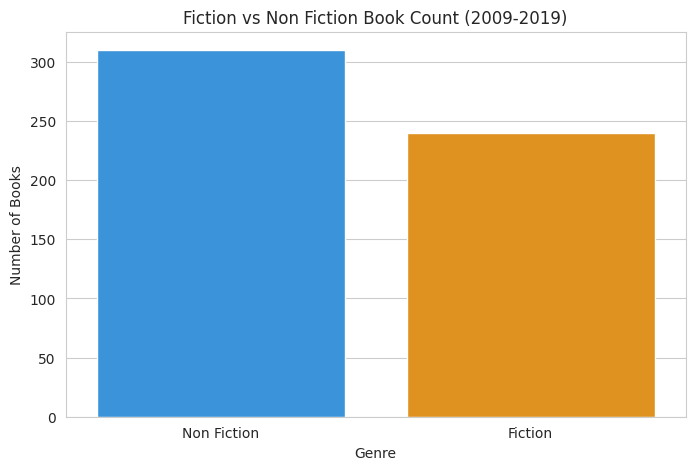

In [36]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Genre', hue='Genre', palette=['#2196F3', '#FF9800'], legend=False)
plt.title('Fiction vs Non Fiction Book Count (2009-2019)')
plt.xlabel('Genre')
plt.ylabel('Number of Books')
plt.savefig('genre_count.png')
plt.show()

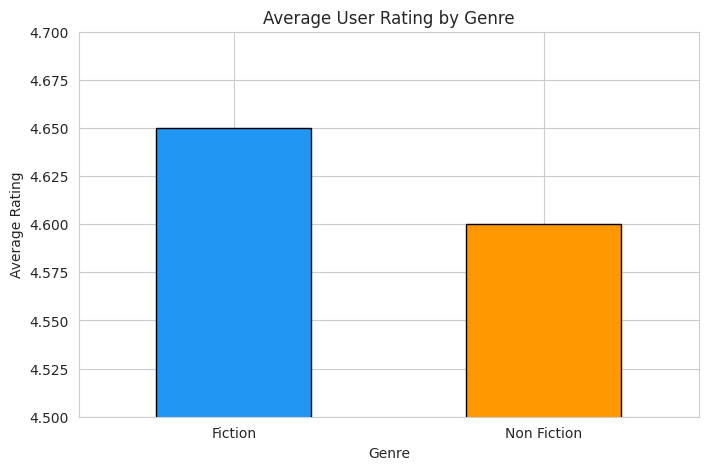

In [37]:
# Which genre is rated higher?
avg_rating = df.groupby('Genre')['User_Rating'].mean().round(2)

plt.figure(figsize=(8,5))
avg_rating.plot(kind='bar', color=['#2196F3', '#FF9800'], edgecolor='black')
plt.title('Average User Rating by Genre')
plt.xlabel('Genre')
plt.ylabel('Average Rating')
plt.xticks(rotation=0)
plt.ylim(4.5, 4.7)
plt.savefig('avg_rating.png')
plt.show()

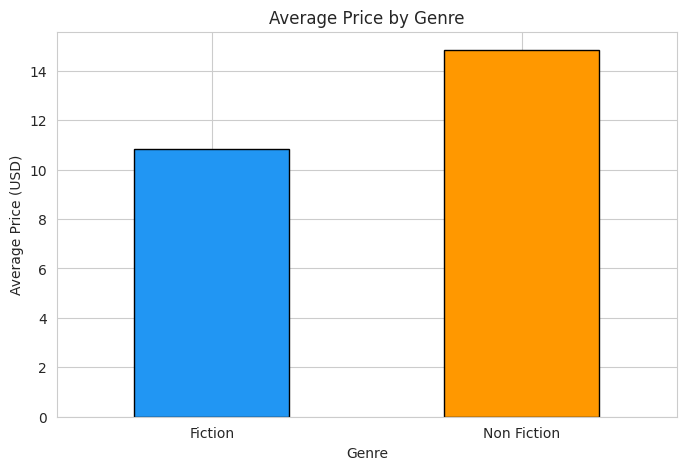

In [38]:
# Which genre costs more?
avg_price = df.groupby('Genre')['Price'].mean().round(2)

plt.figure(figsize=(8,5))
avg_price.plot(kind='bar', color=['#2196F3', '#FF9800'], edgecolor='black')
plt.title('Average Price by Genre')
plt.xlabel('Genre')
plt.ylabel('Average Price (USD)')
plt.xticks(rotation=0)
plt.savefig('avg_price.png')
plt.show()

<Figure size 1200x600 with 0 Axes>

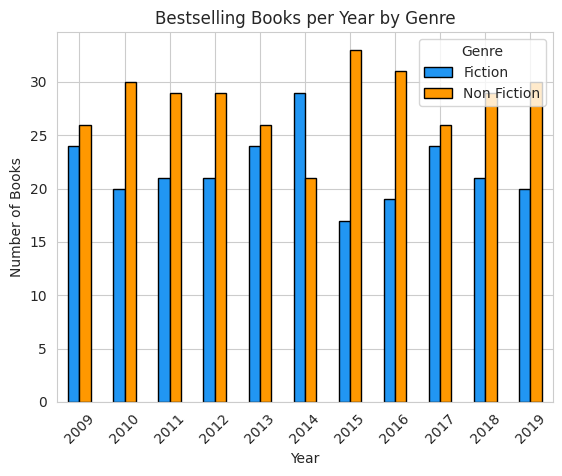

In [39]:
# How did genre distribution change over the years?
yearly = df.groupby(['Year', 'Genre']).size().unstack()

plt.figure(figsize=(12,6))
yearly.plot(kind='bar', color=['#2196F3', '#FF9800'], edgecolor='black')
plt.title('Bestselling Books per Year by Genre')
plt.xlabel('Year')
plt.ylabel('Number of Books')
plt.xticks(rotation=45)
plt.legend(title='Genre')
plt.savefig('yearly_genre.png')
plt.show()

/tmp/ipykernel_58/2453550163.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_authors.values, y=top_authors.index, palette='Blues_r')


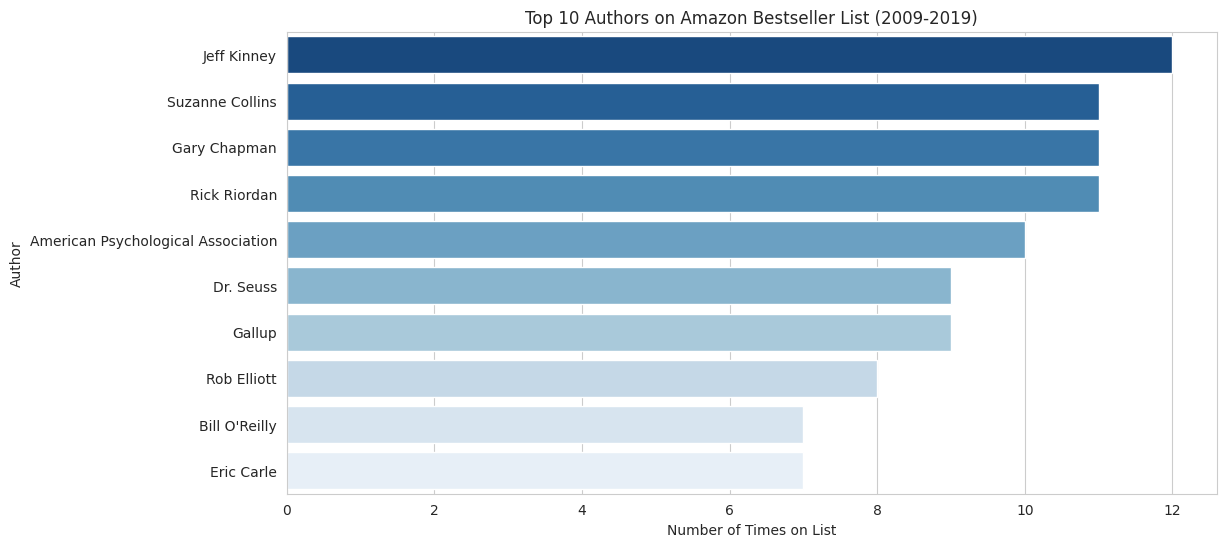

In [40]:
# Who appeared most on the bestseller list?
top_authors = df['Author'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_authors.values, y=top_authors.index, palette='Blues_r')
plt.title('Top 10 Authors on Amazon Bestseller List (2009-2019)')
plt.xlabel('Number of Times on List')
plt.ylabel('Author')
plt.savefig('top_authors.png')
plt.show()

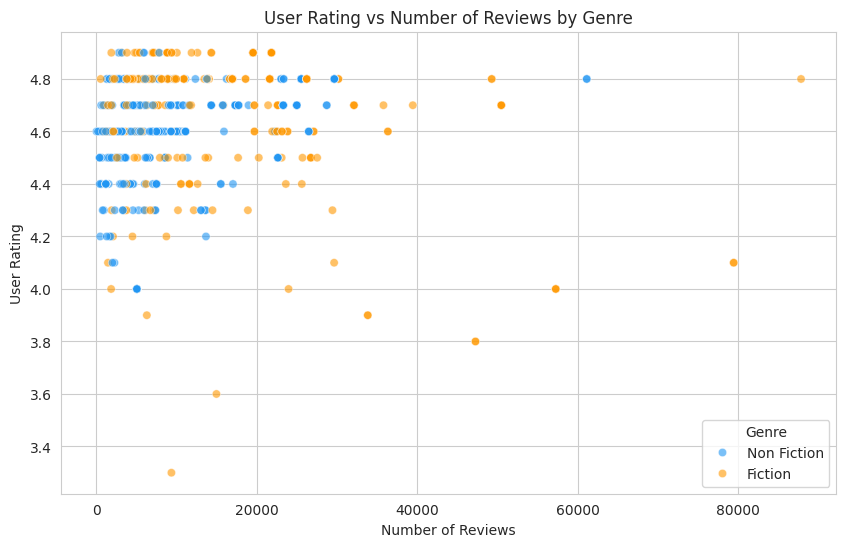

In [41]:
# Do highly reviewed books have better ratings?
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Reviews', y='User_Rating', 
                hue='Genre', palette=['#2196F3', '#FF9800'], alpha=0.6)
plt.title('User Rating vs Number of Reviews by Genre')
plt.xlabel('Number of Reviews')
plt.ylabel('User Rating')
plt.savefig('rating_vs_reviews.png')
plt.show()

## Visual Insights

1. Non Fiction dominates in volume but Fiction is rated slightly higher
2. Non Fiction commands a higher price despite similar ratings
3. 2015 saw the peak of Non Fiction bestsellers
4. A small group of authors repeatedly dominate the bestseller list
5. Books with more reviews don't necessarily have higher ratings — 
   popularity and quality are different things